<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Stochastic-modeling-and-derivatives---TD-5" data-toc-modified-id="Stochastic-modeling-and-derivatives---TD-5-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Stochastic modeling and derivatives - TD 5</a></span><ul class="toc-item"><li><span><a href="#Exercice-1:-calcul-numérique-de-la-volatilité-implicite-d'une-option" data-toc-modified-id="Exercice-1:-calcul-numérique-de-la-volatilité-implicite-d'une-option-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Exercice 1: calcul numérique de la volatilité implicite d'une option</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#$\blacktriangleright$-Q1" data-toc-modified-id="$\blacktriangleright$-Q1-1.1.0.1"><span class="toc-item-num">1.1.0.1&nbsp;&nbsp;</span>$\blacktriangleright$ Q1</a></span></li><li><span><a href="#$\blacktriangleright$-Q2:-Méthode-de-Newton" data-toc-modified-id="$\blacktriangleright$-Q2:-Méthode-de-Newton-1.1.0.2"><span class="toc-item-num">1.1.0.2&nbsp;&nbsp;</span>$\blacktriangleright$ Q2: Méthode de Newton</a></span></li><li><span><a href="#$\blacktriangleright$-Q2:-Méthode-par-dichotomie-(facultatif)" data-toc-modified-id="$\blacktriangleright$-Q2:-Méthode-par-dichotomie-(facultatif)-1.1.0.3"><span class="toc-item-num">1.1.0.3&nbsp;&nbsp;</span>$\blacktriangleright$ Q2: Méthode par dichotomie (facultatif)</a></span></li></ul></li></ul></li><li><span><a href="#Exercice-2:-plotting-the-IV-from-true-data" data-toc-modified-id="Exercice-2:-plotting-the-IV-from-true-data-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Exercice 2: plotting the IV from true data</a></span><ul class="toc-item"><li><span><a href="#Uploading-data" data-toc-modified-id="Uploading-data-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Uploading data</a></span></li><li><span><a href="#Computing-the-IV-for-all-available-strikes" data-toc-modified-id="Computing-the-IV-for-all-available-strikes-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Computing the IV for all available strikes</a></span></li><li><span><a href="#Plotting-the-IV-in-log-forward-moneyness-and-in-Delta" data-toc-modified-id="Plotting-the-IV-in-log-forward-moneyness-and-in-Delta-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Plotting the IV in log-forward moneyness and in Delta</a></span></li></ul></li></ul></li></ul></div>

# Stochastic modeling and derivatives - TD 5

In [1]:
import numpy as np

## Exercice 1: calcul numérique de la volatilité implicite d'une option

$\bullet$ On se propose d'écrire un code qui calcule la volatilité implicite d'une option put à partir de son prix.

#### $\blacktriangleright$ Q1

On aura besoin, en premier lieu, de coder la formule pour le prix du Call dans le modèle de Black-Scholes à paramètre constants (incluant un taux d'intérêt $r$ et un taux de dividende ou taux de repo $q$), que l'on rappelle ici:

$$
\mathrm{Call}_{BS}(t,S,T,K,\sigma) = e^{-r \, (T-t)} \bigl(F_t^T \, \mathcal{N}(d_+) - K\, \mathcal{N}(d_-) \bigr)
$$

où $F_t^T = S \, e^{(r-q) \, (T-t)}$ est le prix forward de $S$,

$$
d_+ = \frac 1{\sigma \sqrt{T-t}} \log \frac{F_t^T}K + \frac 12 \sigma \sqrt{T-t},
\qquad
d_- = d_+ - \sigma \sqrt{T-t},
$$

et $\mathcal{N}(x) = \int_{-\infty}^x \frac 1{\sqrt{2 \pi}} e^{-\frac{y^2} 2} dy$ est la fonction de répartition gaussienne.

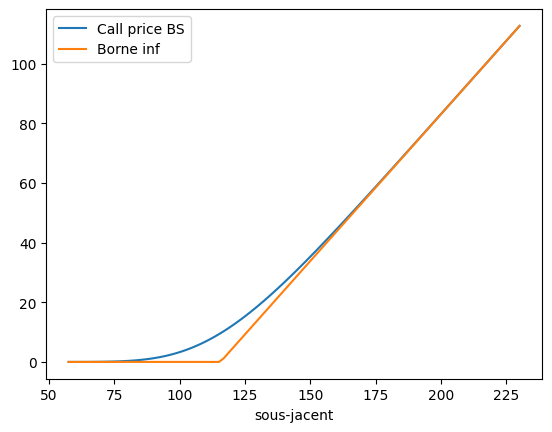

In [2]:
import scipy.stats as sps
import matplotlib.pyplot as plt

def Call_BS_core(tau, K, DF, F, sigma):
    """
    Prix du Call Black-Scholes en fonction de
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)

    d_plus = np.log(F/K)/sigma_sqrt_tau + sigma_sqrt_tau/2.
    
    d_minus = d_plus - sigma_sqrt_tau

    ####################
    ## TO DO: compléter
    ####################
    prix_call = DF * (F * sps.norm.cdf(d_plus) - K * sps.norm.cdf(d_minus))

    return prix_call

def Call_BS(t, S, T, K, r, q, sigma):
    """
    Prix du Call Black-Scholes en fonction des paramètres BS usuels.
    """
    tau = T - t
    DF = np.exp(-r*tau)
    F = S * np.exp((r-q)*tau)
    
    return Call_BS_core(tau, K, DF, F, sigma)

##########
## Test
##########
T = 0.5
K = 115
t = 0
sigma = 0.3
r = 0.02
q = 0.03
S = np.linspace(K/2, K*2, 100)

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp((r-q)*tau)

call_price = Call_BS_core(tau, K, DF, F, sigma)

borne_inf = np.maximum(DF*(F - K), 0)

plt.plot( S , call_price, label="Call price BS")
plt.plot( S , borne_inf, label="Borne inf")
plt.xlabel("sous-jacent")
plt.legend(loc="best")
plt.show()

In [3]:
def Put_BS_core(tau, K, DF, F, sigma):
    """
    Prix du Call Black-Scholes en fonction de
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)

    d_plus = np.log(F/K)/sigma_sqrt_tau + sigma_sqrt_tau/2.
    
    d_minus = d_plus - sigma_sqrt_tau

    ####################
    ## TO DO: compléter
    ####################
    prix_put = DF * (K * sps.norm.cdf(-d_minus) - F * sps.norm.cdf(-d_plus))

    return prix_put

def Put_BS(t, S, T, K, r, q, sigma):
    """
    Prix du Call Black-Scholes en fonction des paramètres BS usuels.
    """
    tau = T - t
    DF = np.exp(-r*tau)
    F = S * np.exp((r-q)*tau)
    
    return Put_BS_core(tau, K, DF, F, sigma)

#### $\blacktriangleright$ Q2: Méthode de Newton 

$\bullet$ Pour appliquer la méthode de Newton, nous avons besoin de l'expression du Vega pour un Put (ou put) Black-Scholes en présence d'un taux d'intérêt sans risque $r$ et d'un taux de dividende (ou taux de repo) $q$.

Pour rappel:

$$
\mathrm{Vega}(t, S, T, K)
= S \, e^{-q(T-t)} \sqrt{T-t} \, \mathcal{N}'(d_+)
= \frac {S \, e^{-q(T-t)} \sqrt{T-t}}{\sqrt{2 \pi} } e^{- \frac 12 (d_+)^2}
$$

où 
$$
d_+ = \frac 1{\sigma \sqrt{T-t}} \log \frac{F_t^T}K + \frac 12 \sigma \sqrt{T-t},
$$

et $F_t^T = S_t \, e^{(r-q)(T-t)}$ est le prix forward de $S$. 

In [4]:
def Vega_core(tau, K, DF, F, sigma):
    """
    Vega d'un call Black-Scholes en fonction de
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)
    
    d_plus = np.log(F/K) / sigma_sqrt_tau + sigma_sqrt_tau / 2.

    ####################
    ## TO DO: compléter
    ####################
    vega = DF * F * np.sqrt(tau) * sps.norm.pdf(d_plus)
    
    return vega

def Vega(t, S, T, K, r, q, sigma):
    """
    Vega d'un call Black-Scholes en fonction des paramètres BS usuels.
    """
    tau = T - t
    DF = np.exp(-r*tau)
    F = S * np.exp((r-q)*tau)
    
    return Vega_core(tau, K, DF, F, sigma)

In [5]:
def Delta_core(tau, K, DF, F, sigma):
    """
    Vega d'un call Black-Scholes en fonction de
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)
    
    d_plus = np.log(F/K) / sigma_sqrt_tau + sigma_sqrt_tau / 2.

    ####################
    ## TO DO: compléter
    ####################
    delta = DF * sps.norm.cdf(d_plus)
    
    return delta

def Dega(t, S, T, K, r, q, sigma):
    """
    Delta d'un call Black-Scholes en fonction des paramètres BS usuels.
    """
    tau = T - t
    DF = np.exp(-r*tau)
    F = S * np.exp((r-q)*tau)
    
    return Delta_core(tau, K, DF, F, sigma)

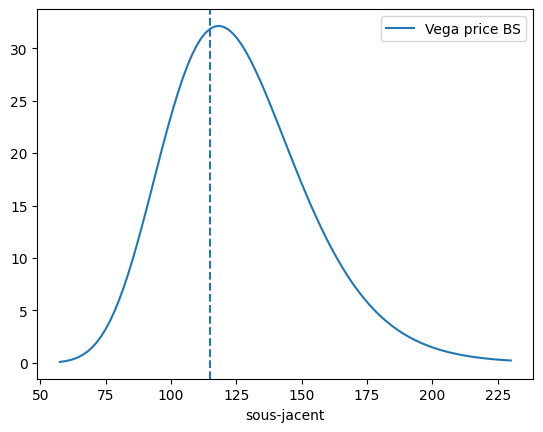

In [6]:
S = np.linspace(K/2, K*2, 100)
F = S * np.exp((r-q)*tau)

vega_price = Vega_core(tau, K, DF, F, sigma)

plt.plot( S , vega_price, label="Vega price BS")
plt.axvline(x=K, linestyle="--")
plt.xlabel("sous-jacent")
plt.legend(loc="best")
plt.show()

$\bullet$ Compléter le code ci-dessous qui implémente la méthode de Newton.

In [7]:
def volImplCallCore_Newton(tau, K, DF, F, target_price, initial_point='automatic', prix_tol = 1.e-3, max_iter=50):
    """
    Volatilité implicite d'un Call de prix = target_price, lorsque les autres paramètres sont:
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    
    Méthode: Newton.
    """
    if initial_point == 'automatic':
        #############################################
        ## Un bon point de départ sigma_0: cf cours 5
        #############################################
        vol = np.sqrt( 2/tau * np.abs(np.log(F/K)) )
    else:
        vol = initial_point

    if vol==0: 
        vol=0.0001 # on prend 1 basis point pour eviter un point initial nul si option ATM
    
    current_price = Call_BS_core(tau, K, DF, F, vol)
    
    critere_arret = np.abs(current_price - target_price)
    iterations = 0
    
    while ( (critere_arret > prix_tol) & (iterations < max_iter) ):
        iterations = iterations + 1
        
        ####################################################
        ## Implémenter l'itération de la méthode de Newton:
        ## voir cours 5
        ####################################################
        vol = vol - (current_price - target_price) / Vega_core(tau, K, DF, F, vol)
        
        current_price = Call_BS_core(tau, K, DF, F, vol)
        
        critere_arret = np.abs(current_price - target_price)
    
    return vol, iterations

In [8]:
def volImplPutCore_Newton(tau, K, DF, F, target_price, initial_point='automatic', prix_tol = 1.e-3, max_iter=50):
    """
    Volatilité implicite d'un Put de prix = target_price, lorsque les autres paramètres sont:
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    
    Méthode: Newton.
    """
    if initial_point == 'automatic':
        #############################################
        ## Un bon point de départ sigma_0: cf cours 5
        #############################################
        vol = np.sqrt( 2/tau * np.abs(np.log(F/K)) )
    else:
        vol = initial_point

    if vol==0: 
        vol=0.0001 # on prend 1 basis point pour eviter un point initial nul si option ATM
    
    current_price = Put_BS_core(tau, K, DF, F, vol)
    
    critere_arret = np.abs(current_price - target_price)
    iterations = 0
    
    while ( (critere_arret > prix_tol) & (iterations < max_iter) ):
        iterations = iterations + 1
        
        ####################################################
        ## Implémenter l'itération de la méthode de Newton:
        ## voir cours 5
        ####################################################
        vol = vol - (current_price - target_price) / Vega_core(tau, K, DF, F, vol)
        
        current_price = Put_BS_core(tau, K, DF, F, vol)
        
        critere_arret = np.abs(current_price - target_price)
    
    return vol, iterations

On teste

In [19]:
T = 0.822000
K = 95.490000
t = 0
S = 91.100000
r = 0.062000
q = 0.025000

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp((r-q)*tau)

########################################
## Vol implicite d'un prix de Call donné
########################################
target_price = 6.202368
vol_Newton, iterations = volImplCallCore_Newton(tau, K, DF, F, target_price, initial_point='automatic', prix_tol = 1.e-6)

print("Prix du Call: %1.6f \n" %target_price)
print("Vol implicite par Newton: %1.4f" %vol_Newton)
print("Nombre iterations dans la méthode de Newton: %1.0f" %iterations)

print("On reprice avec la vol implicite obtenue: prix du Call = %1.6f \n" %Call_BS_core(tau, K, DF, F, vol_Newton))

################################################
## Test: retrouver le paramètre de volatilité
## Black-Scholes
################################################
vol_initiale = 0.28

target_price = Call_BS_core(tau, K, DF, F, vol_initiale)

vol_Newton, iterations = volImplCallCore_Newton(tau, K, DF, F, target_price, initial_point='automatic', prix_tol = 1.e-10)

print("Test: retrouve-t-on le paramètre de volatilité Black-Scholes? \n")
print("Vol initiale: %1.4f" %vol_initiale)
print("Vol Newton: %1.4f" %vol_Newton)
print("Nombre iterations dans la méthode de Newton: %1.0f" %iterations)

Prix du Call: 6.202368 

Vol implicite par Newton: 0.2131
Nombre iterations dans la méthode de Newton: 2
On reprice avec la vol implicite obtenue: prix du Call = 6.202368 

Test: retrouve-t-on le paramètre de volatilité Black-Scholes? 

Vol initiale: 0.2800
Vol Newton: 0.2800
Nombre iterations dans la méthode de Newton: 3


#### $\blacktriangleright$ Q2: Méthode par dichotomie (facultatif)

$\bullet$ Compléter le code ci-dessous qui implémente la méthode de recherche de la volatilité implicite par dichotomie.

In [10]:
def volImplCallCore_dichotomie(tau, K, DF, F, target_price, prix_tol = 1.e-3, max_iter=50, a = 0.001, b = 2.):
    """
    Volatilité implicite d'un Call de prix = target_price, lorsque les autres paramètres sont:
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    
    Méthode de calcul: dichotomie sur l'intervalle [a, b]. 
    """
    prix_min = Call_BS_core(tau, K, DF, F, a)
    prix_max = Call_BS_core(tau, K, DF, F, b)
    
    ######################################################
    ## On verifie si le prix donné est entre les bornes
    ## choisies pour appliquer la méthode de bissection
    ######################################################
    check = (prix_min < target_price < prix_max)
    
    if check == False:
        print("""ATTENTION: Prix en dehors des bornes de bissection.
           Calcul de vol impossible pour les bornes choisies.
           Cette fonction renvoie vol = 0.""")
        return 0
    
    else:
        vol_min = a
        vol_max = b
        
        vol = (vol_min + vol_max) / 2
        prix_milieu = Call_BS_core(tau, K, DF, F, vol)
        
        critere_arret = np.abs(prix_milieu - target_price)
        iterations = 0
        
        while ( (critere_arret > prix_tol) & (iterations < max_iter) ):
            iterations = iterations + 1
            
            if prix_milieu - target_price > 0:
                ################################
                ## TO DO: mettre à jour vol_max
                ################################
                vol_max = (vol_min + vol_max) / 2
                vol = (vol_min + vol_max) / 2
            else:
                #######################################
                ## TO DO: mettre à jour vol_min et vol
                #######################################
                vol_min = (vol_min + vol_max) / 2
                vol = (vol_min + vol_max) / 2
            
            prix_milieu = Call_BS_core(tau, K, DF, F, vol)
            
            critere_arret = np.abs(prix_milieu - target_price)
        
        return vol, iterations

On remarquera que l'on n'a pas eu besoin d'utiliser le Vega; dans la méthode de dichotomie, on n'évalue que le prix de l'option.

On teste:

In [11]:
T = 0.5
K = 115
t = 0
S = 100
r = 0.02
q = 0.03

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp((r-q)*tau)

########################################
## Vol implicite d'un prix de Call donné
########################################
target_price = 20
vol_dichotomie, iterations = volImplCallCore_dichotomie(tau, K, DF, F, target_price, prix_tol = 1.e-2)

print("Prix du Call: %1.4f \n" %target_price)
print("Vol implicite par dichotomie: %1.4f" %vol_dichotomie)
print("Nombre iterations dans la méthode de dichotomie: %1.0f \n" %iterations)

print("On reprice avec la vol implicite obtenue: prix du Call = %1.4f \n" %Call_BS_core(tau, K, DF, F, vol_dichotomie))

################################################
## Test: retrouver le paramètre de volatilité
## Black-Scholes
################################################
vol_initiale = 0.28

target_price = Call_BS_core(tau, K, DF, F, vol_initiale)

vol_dichotomie, iterations = volImplCallCore_dichotomie(tau, K, DF, F, target_price, prix_tol = 1.e-2)

print("Test: retrouve-t-on le paramètre de volatilité Black-Scholes? \n")
print("Vol initiale: %1.4f" %vol_initiale)
print("Vol bissection: %1.4f" %vol_dichotomie)
print("Nombre iterations dans la méthode de bissection: %1.0f" %iterations)

Prix du Call: 20.0000 

Vol implicite par dichotomie: 0.9185
Nombre iterations dans la méthode de dichotomie: 8 

On reprice avec la vol implicite obtenue: prix du Call = 20.0088 

Test: retrouve-t-on le paramètre de volatilité Black-Scholes? 

Vol initiale: 0.2800
Vol bissection: 0.2802
Nombre iterations dans la méthode de bissection: 9


## Exercice 2: plotting the IV from true data

### Uploading data

In [12]:
import pandas as pd
tau=90/252 # time-to-maturity, maturity June 2021
df = pd.read_csv('2021Fev19_OESB.csv', sep=";") 
df

,Type,Strike,Bid,Ask,Date,Time
0,Call,97.5,0.05,0.15,02/19/2021,18:57:03
1,Call,95.0,0.10,0.20,02/19/2021,18:57:03
2,Call,94.0,0.15,0.25,02/19/2021,18:57:03
3,Call,93.0,0.20,0.30,02/19/2021,18:57:03
4,Call,92.5,0.25,0.35,02/19/2021,18:57:03
...,...,...,...,...,...,...
104,Put,63.0,0.05,0.20,02/19/2021,18:57:03
105,Put,62.5,0.05,0.20,02/19/2021,18:57:03
106,Put,62.0,0.05,0.15,02/19/2021,18:57:03
107,Put,61.0,0.05,0.15,02/19/2021,18:57:03


### Computing the IV for all available strikes

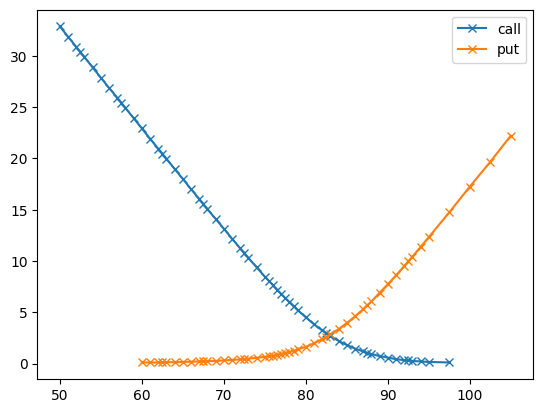

In [13]:
df["Mid"]=(df.Bid+df.Ask)/2 # we add a columun corresponding to the mid price
plt.plot(df[(df.Type=="Call")].Strike, df[(df.Type=="Call")].Mid, marker="x", label="call")
plt.plot(df[(df.Type=="Put")].Strike, df[(df.Type=="Put")].Mid, marker="x", label="put")
plt.legend()

##### Computing the forward and the discount factor

In [14]:
# we compute all the strikes
list_of_strikes=[]
for strikes in df.Strike:
    if strikes not in list_of_strikes:
        list_of_strikes.append(strikes)
list_of_strikes=np.sort(list_of_strikes)

# we compute the strikes in common to calls and puts, and then extract the forward by linear regression in the call-put parity
# TO COMPLETE

In [15]:
# solution
DiscountFactor, Forward = 0.999996, 82.840076

##### Computing the IV

In [16]:
IV=[]
strike_IV=[]
delta_IV=[]

for strikes in list_of_strikes:
    call_empty=df[(df.Type=="Call") & (df.Strike==strikes)].empty
    put_empty=df[(df.Type=="Put") & (df.Strike==strikes)].empty
    if (call_empty<=0.0): # we compute the IV from the call price
        call_price = df[(df.Type=="Call") & (df.Strike==strikes)].Mid.values[0]

        implied_vol, iterations = volImplCallCore_Newton(tau, strikes, DiscountFactor, Forward, call_price)

        delta = Delta_core(tau, strikes, DiscountFactor, Forward, implied_vol)

        IV.append(implied_vol)
        strike_IV.append(strikes)
        delta_IV.append(delta)
        
    elif (put_empty<=0.0): # we compute the IV from the put price
        put_price = df[(df.Type=="Put") & (df.Strike==strikes)].Mid.values[0]
  
        implied_vol, iterations = volImplPutCore_Newton(tau, strikes, DiscountFactor, Forward, put_price)
        delta = Delta_core(tau, strikes, DiscountFactor, Forward, implied_vol)
        IV.append(implied_vol)
        strike_IV.append(strikes)
        delta_IV.append(delta)

### Plotting the IV in log-forward moneyness and in Delta

TypeError: unsupported operand type(s) for /: 'list' and 'float'

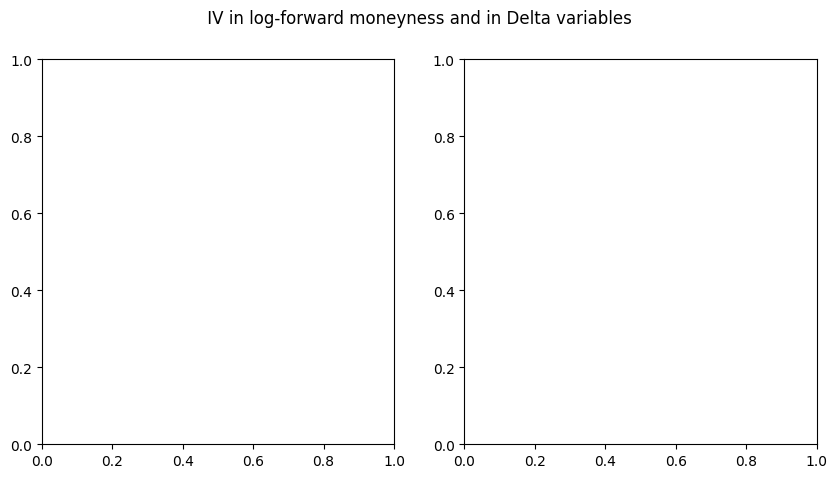

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(' IV in log-forward moneyness and in Delta variables')

ax1.plot(np.log(strike_IV/Forward), IV, label="IV")
ax1.set_xlabel('Log-forward moneyness')
ax1.set_ylabel('IV')
ax1.legend()

ax2.plot(delta_IV, IV, label="IV")
ax2.set_xlabel('Delta')
ax2.set_ylabel('IV')
ax2.legend()

plt.show()